In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
!nvidia-smi

In [2]:
df=pd.read_csv(r"C:\Users\vivaa\OneDrive\Desktop\Personal Projects\Financial Intelligence Platform\Data\Raw_Data\AAPL_daily.csv", parse_dates=True)
#import yfinance as yf
#tickers=["AAPL"]#"TCS.NS","BAJAJ-AUTO.NS"]
#df = yf.download(
#    tickers,
#    start="2022-01-01")
#df = yf.download("TCS.NS", start="2018-01-01", auto_adjust=False)



In [3]:
df.head()

,Price,Adj Close,Close,High,Low,Open,Volume
0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
1,Date,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-01-04,23.730945587158203,26.337499618530273,26.342500686645508,25.5,25.65250015258789,270597600
3,2016-01-05,23.136266708374023,25.677499771118164,26.462499618530273,25.602500915527344,26.4375,223164000
4,2016-01-06,22.683496475219727,25.174999237060547,25.592500686645508,24.967500686645508,25.139999389648438,273829600


In [4]:
df.shape

(2546, 7)

In [5]:
df.columns

Index(['Price', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [6]:
column=['date', 'close','close1', 'high', 'low', 'open', 'volume']
df.columns=column

In [7]:
df.drop(index=[0,1],axis=0,inplace=True)
df.drop(columns=['close1'],axis=1,inplace=True)
df.reset_index(drop=True,inplace=True)

In [8]:
df.shape

(2544, 6)

In [9]:
df.dtypes

date      object
close     object
high      object
low       object
open      object
volume    object
dtype: object

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2544 entries, 0 to 2543
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    2544 non-null   object
 1   close   2544 non-null   object
 2   high    2544 non-null   object
 3   low     2544 non-null   object
 4   open    2544 non-null   object
 5   volume  2544 non-null   object
dtypes: object(6)
memory usage: 119.4+ KB


In [11]:
df.describe()

,date,close,high,low,open,volume
count,2544,2544,2544,2544,2544,2544
unique,2544,2509,2417,2443,2424,2537
top,2016-01-04,25.899044036865234,43.75,133.77000427246094,24.0,146640000
freq,1,2,3,3,3,2


In [12]:
df.isnull().sum()

date      0
close     0
high      0
low       0
open      0
volume    0
dtype: int64

In [13]:
df["date"] = pd.to_datetime(df["date"])
for i in ['close', 'high', 'low', 'open', 'volume']:
    df[i]=df[i].astype(float)

In [14]:
df["date"].min()

Timestamp('2016-01-04 00:00:00')

In [15]:
df.dtypes

date      datetime64[ns]
close            float64
high             float64
low              float64
open             float64
volume           float64
dtype: object

In [16]:
df.head()

,date,close,high,low,open,volume
0,2016-01-04,23.730946,26.342501,25.500000,25.652500,270597600.0
1,2016-01-05,23.136267,26.462500,25.602501,26.437500,223164000.0
2,2016-01-06,22.683496,25.592501,24.967501,25.139999,273829600.0
3,2016-01-07,21.726149,25.032499,24.107500,24.670000,324377600.0
4,2016-01-08,21.841034,24.777500,24.190001,24.637501,283192000.0


In [17]:
df.describe()

,date,close,high,low,open,volume
count,2544,2544.000000,2544.000000,2544.000000,2544.000000,2.544000e+03
mean,2021-01-21 05:13:01.132075520,115.927183,119.424256,116.957686,118.143209,1.012213e+08
min,2016-01-04 00:00:00,20.584820,22.917500,22.367500,22.500000,1.791060e+07
25%,2018-07-12 18:00:00,41.612411,44.471250,43.734375,44.043123,6.089062e+07
50%,2021-01-21 12:00:00,121.896652,126.294998,123.641247,124.875000,8.819755e+07
75%,2023-08-02 06:00:00,172.771172,177.105000,173.620003,175.264999,1.238153e+08
max,2026-02-13 00:00:00,285.922455,288.619995,283.299988,286.200012,5.334788e+08
std,NaN,74.581255,74.916288,73.417324,74.142478,5.788104e+07


In [18]:
#df['daily change'] = (df['open'] - df['open'].shift(1)) / df['open'].shift(1)

In [19]:
# Calculate the 7-day Rolling Mean (Moving Average)
#df['rolling_mean_7'] = df['open'].rolling(window=7).mean()

In [20]:
df.head()

,date,close,high,low,open,volume
0,2016-01-04,23.730946,26.342501,25.500000,25.652500,270597600.0
1,2016-01-05,23.136267,26.462500,25.602501,26.437500,223164000.0
2,2016-01-06,22.683496,25.592501,24.967501,25.139999,273829600.0
3,2016-01-07,21.726149,25.032499,24.107500,24.670000,324377600.0
4,2016-01-08,21.841034,24.777500,24.190001,24.637501,283192000.0


In [21]:
'''df['ma_5']=np.nan
count=0
k=[]
for i in df['close']:  #range(4,2543):
    count+=1
    if(count>4):
        s=0
        for j in range(count-5,count):
            s=s+df['close'][j]
        k.append(s/5)
for i in range(0,2539):
    df['ma_5'][i+4]=k[i]'''

"df['ma_5']=np.nan\ncount=0\nk=[]\nfor i in df['close']:  #range(4,2543):\n    count+=1\n    if(count>4):\n        s=0\n        for j in range(count-5,count):\n            s=s+df['close'][j]\n        k.append(s/5)\nfor i in range(0,2539):\n    df['ma_5'][i+4]=k[i]"

In [22]:
#for i in range(0,2539):
#    df['ma_5'][i+4]=k[i]

In [23]:
#k[2538]

In [24]:
import pandas as pd
import numpy as np

def add_technical_features(df):
    # 1. Create a copy to avoid SettingWithCopy warnings on the original df
    df = df.copy()
    
    # --- BASE CALCULATIONS ---
    # Daily Return (Base for volatility and mean returns)
    # calculated as: (Price_today - Price_yesterday) / Price_yesterday
    df['daily_ret'] = df['close'].pct_change()
    
    # --- 1. ROLLING MEAN RETURNS ---
    # The average daily return over the last N days
    df['roll_mean_ret_5'] = df['daily_ret'].rolling(window=5).mean()
    df['roll_mean_ret_10'] = df['daily_ret'].rolling(window=10).mean()
    
    # --- 2. ROLLING VOLATILITY ---
    # Standard deviation of daily returns (Risk)
    df['roll_vol_5'] = df['daily_ret'].rolling(window=5).std()
    df['roll_vol_20'] = df['daily_ret'].rolling(window=20).std()
    
    # --- 3. MOMENTUM (CUMULATIVE RETURN) ---
    # Total percentage change over the last 10 days
    # Formula: (Price_today - Price_10_days_ago) / Price_10_days_ago
    df['momentum_10'] = df['close'].pct_change(periods=10)
    
    # --- 4. VOLUME CHANGE ---
    # Daily percentage change in volume
    df['vol_change'] = df['volume'].pct_change()
    
    # --- 5. VOLUME ROLLING MEAN ---
    # Average volume over the last 5 days
    df['vol_roll_mean_5'] = df['volume'].rolling(window=5).mean()
    
    # --- 6. MOVING AVERAGE DIFFERENCE (DIVERGENCE) ---
    # How far the current price is from the 10-day moving average
    # Logic: (Price - MA) / MA
    ma_10 = df['close'].rolling(window=10).mean()
    df['ma_diff_10'] = (df['close'] - ma_10) / ma_10
    return df

# --- EXAMPLE USAGE ---
# Assuming you have a dataframe 'df' with 'close' and 'volume' columns:
df = add_technical_features(df)


In [25]:
df.head()

,date,close,high,low,open,volume,daily_ret,roll_mean_ret_5,roll_mean_ret_10,roll_vol_5,roll_vol_20,momentum_10,vol_change,vol_roll_mean_5,ma_diff_10
0,2016-01-04,23.730946,26.342501,25.500000,25.652500,270597600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-05,23.136267,26.462500,25.602501,26.437500,223164000.0,-0.025059,NaN,NaN,NaN,NaN,NaN,-0.175292,NaN,NaN
2,2016-01-06,22.683496,25.592501,24.967501,25.139999,273829600.0,-0.019570,NaN,NaN,NaN,NaN,NaN,0.227033,NaN,NaN
3,2016-01-07,21.726149,25.032499,24.107500,24.670000,324377600.0,-0.042205,NaN,NaN,NaN,NaN,NaN,0.184597,NaN,NaN
4,2016-01-08,21.841034,24.777500,24.190001,24.637501,283192000.0,0.005288,NaN,NaN,NaN,NaN,NaN,-0.126968,275032160.0,NaN


Consider walk-forward validation (train on years 1-5, test on year 6, then train on 2-6, test on 7, etc.)

#Backtesting

In [26]:
df['target']=np.log(df['close'].shift(-5)/df['close'])

In [27]:
df.dropna(inplace=True)
df.reset_index(drop=True,inplace=True)

In [28]:
df['target']

0       0.010795
1      -0.016413
2      -0.030481
3      -0.000319
4       0.017011
          ...   
2514    0.017865
2515    0.016401
2516   -0.002652
2517   -0.051826
2518   -0.082800
Name: target, Length: 2519, dtype: float64

In [29]:
df.dtypes

date                datetime64[ns]
close                      float64
high                       float64
low                        float64
open                       float64
volume                     float64
daily_ret                  float64
roll_mean_ret_5            float64
roll_mean_ret_10           float64
roll_vol_5                 float64
roll_vol_20                float64
momentum_10                float64
vol_change                 float64
vol_roll_mean_5            float64
ma_diff_10                 float64
target                     float64
dtype: object

In [30]:
df.head()

,date,close,high,low,open,volume,daily_ret,roll_mean_ret_5,roll_mean_ret_10,roll_vol_5,roll_vol_20,momentum_10,vol_change,vol_roll_mean_5,ma_diff_10,target
0,2016-02-02,21.282389,24.010000,23.570000,23.855000,149428800.0,-0.020222,-0.010713,-0.001811,0.037028,0.026989,-0.022554,-0.087591,265412560.0,-0.025678,0.010795
1,2016-02-03,21.703623,24.209999,23.520000,23.750000,183857200.0,0.019793,0.006387,0.000034,0.021958,0.027105,-0.004546,0.230400,195488240.0,-0.005943,-0.016413
2,2016-02-04,21.878014,24.332500,23.797501,23.965000,185886800.0,0.008035,0.006560,0.001344,0.021969,0.026911,0.008558,0.011039,188122560.0,0.001193,-0.030481
3,2016-02-05,21.293692,24.230000,23.422501,24.129999,185672400.0,-0.026708,-0.005690,-0.006644,0.019391,0.025879,-0.067934,-0.001153,173723840.0,-0.018576,-0.000319
4,2016-02-08,21.517912,23.924999,23.260000,23.282499,216085600.0,0.010530,-0.001714,-0.003638,0.020462,0.025969,-0.039365,0.163800,184186160.0,-0.004195,0.017011


In [31]:
X=df.drop(columns=['target'])
y=df['target']
X.drop(columns=["date"],inplace=True)
X.reset_index(drop=True)


,close,high,low,open,volume,daily_ret,roll_mean_ret_5,roll_mean_ret_10,roll_vol_5,roll_vol_20,momentum_10,vol_change,vol_roll_mean_5,ma_diff_10
0,21.282389,24.010000,23.570000,23.855000,149428800.0,-0.020222,-0.010713,-0.001811,0.037028,0.026989,-0.022554,-0.087591,265412560.0,-0.025678
1,21.703623,24.209999,23.520000,23.750000,183857200.0,0.019793,0.006387,0.000034,0.021958,0.027105,-0.004546,0.230400,195488240.0,-0.005943
2,21.878014,24.332500,23.797501,23.965000,185886800.0,0.008035,0.006560,0.001344,0.021969,0.026911,0.008558,0.011039,188122560.0,0.001193
3,21.293692,24.230000,23.422501,24.129999,185672400.0,-0.026708,-0.005690,-0.006644,0.019391,0.025879,-0.067934,-0.001153,173723840.0,-0.018576
4,21.517912,23.924999,23.260000,23.282499,216085600.0,0.010530,-0.001714,-0.003638,0.020462,0.025969,-0.039365,0.163800,184186160.0,-0.004195
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2514,269.757599,270.489990,259.209991,260.029999,73913400.0,0.040581,0.011303,0.005710,0.017725,0.015897,0.056667,-0.200447,64909220.0,0.059432
2515,269.228088,271.880005,267.609985,269.200012,64394700.0,-0.001963,0.008671,0.008969,0.018695,0.015574,0.092339,-0.128782,67858500.0,0.047985
2516,276.231506,278.950012,272.290009,272.290009,90545700.0,0.026013,0.015290,0.011186,0.017546,0.015901,0.116455,0.406105,77710040.0,0.063321
2517,275.652069,279.500000,273.230011,278.130005,52977400.0,-0.002098,0.013436,0.010693,0.019044,0.015755,0.110972,-0.414910,74854920.0,0.049962


In [32]:
test_size = 0.2
split_index = int(len(df) * (1 - test_size))
print(split_index)
X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]


2015


In [33]:
X_test.tail()

,close,high,low,open,volume,daily_ret,roll_mean_ret_5,roll_mean_ret_10,roll_vol_5,roll_vol_20,momentum_10,vol_change,vol_roll_mean_5,ma_diff_10
2514,269.757599,270.489990,259.209991,260.029999,73913400.0,0.040581,0.011303,0.005710,0.017725,0.015897,0.056667,-0.200447,64909220.0,0.059432
2515,269.228088,271.880005,267.609985,269.200012,64394700.0,-0.001963,0.008671,0.008969,0.018695,0.015574,0.092339,-0.128782,67858500.0,0.047985
2516,276.231506,278.950012,272.290009,272.290009,90545700.0,0.026013,0.015290,0.011186,0.017546,0.015901,0.116455,0.406105,77710040.0,0.063321
2517,275.652069,279.500000,273.230011,278.130005,52977400.0,-0.002098,0.013436,0.010693,0.019044,0.015755,0.110972,-0.414910,74854920.0,0.049962
2518,277.859985,280.910004,276.929993,277.119995,50453400.0,0.008010,0.014109,0.011619,0.018713,0.015676,0.121271,-0.047643,66456920.0,0.046394


In [34]:
X_train.dtypes

close               float64
high                float64
low                 float64
open                float64
volume              float64
daily_ret           float64
roll_mean_ret_5     float64
roll_mean_ret_10    float64
roll_vol_5          float64
roll_vol_20         float64
momentum_10         float64
vol_change          float64
vol_roll_mean_5     float64
ma_diff_10          float64
dtype: object

In [35]:
print(X_train.index.max())
print(X_test.index.min())

2014
2015


In [36]:
from xgboost import XGBRegressor

#model = XGBRegressor(
#    n_estimators=300,
#    max_depth=4,
#    learning_rate=0.05,
#    random_state=42
#)
model = XGBRegressor(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.03,
    random_state=42
)

model.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
y_pred = model.predict(X_test)


In [ ]:
y_pred

array([-0.00670888,  0.00312012, -0.00327208,  0.00498538, -0.00321961,
        0.02514828,  0.02295345,  0.00512905, -0.00517353, -0.01259491,
       -0.02437115,  0.00030105,  0.02961154,  0.02962583,  0.03244095,
        0.03221925,  0.03963256,  0.01650103, -0.00187751,  0.01133075,
        0.01506648,  0.02150767,  0.01169915,  0.00257865, -0.00344258,
        0.00518999,  0.0012704 ,  0.00810427, -0.0127548 ,  0.00540617,
        0.00116962, -0.00010486, -0.00450707, -0.00101774, -0.00632755,
       -0.01535579, -0.01812831, -0.00963186, -0.0042197 ,  0.01145613,
        0.02168544,  0.01674542,  0.02821314,  0.02264591,  0.02761874,
        0.03660489, -0.00388347, -0.00817547,  0.0158581 ,  0.01582549,
        0.01085214, -0.03940988, -0.00692352, -0.0172889 ,  0.01375029,
        0.01948751,  0.01657658,  0.01233241,  0.00458713,  0.00934187,
        0.00513585, -0.00469703, -0.01645018,  0.01425852,  0.00403573,
        0.01355336,  0.01009698, -0.00572771, -0.00518134, -0.00

In [ ]:
df.tail(5)

,date,close,high,low,open,volume,daily_ret,roll_mean_ret_5,roll_mean_ret_10,roll_vol_5,roll_vol_20,momentum_10,vol_change,vol_roll_mean_5,ma_diff_10,target
2514,2026-02-02,269.757599,270.489990,259.209991,260.029999,73913400.0,0.040581,0.011303,0.005710,0.017725,0.015897,0.056667,-0.200447,64909220.0,0.059432,0.017865
2515,2026-02-03,269.228088,271.880005,267.609985,269.200012,64394700.0,-0.001963,0.008671,0.008969,0.018695,0.015574,0.092339,-0.128782,67858500.0,0.047985,0.016401
2516,2026-02-04,276.231506,278.950012,272.290009,272.290009,90545700.0,0.026013,0.015290,0.011186,0.017546,0.015901,0.116455,0.406105,77710040.0,0.063321,-0.002652
2517,2026-02-05,275.652069,279.500000,273.230011,278.130005,52977400.0,-0.002098,0.013436,0.010693,0.019044,0.015755,0.110972,-0.414910,74854920.0,0.049962,-0.051826
2518,2026-02-06,277.859985,280.910004,276.929993,277.119995,50453400.0,0.008010,0.014109,0.011619,0.018713,0.015676,0.121271,-0.047643,66456920.0,0.046394,-0.082800


In [ ]:
X_test.tail()

,close,high,low,open,volume,daily_ret,roll_mean_ret_5,roll_mean_ret_10,roll_vol_5,roll_vol_20,momentum_10,vol_change,vol_roll_mean_5,ma_diff_10
2514,269.757599,270.489990,259.209991,260.029999,73913400.0,0.040581,0.011303,0.005710,0.017725,0.015897,0.056667,-0.200447,64909220.0,0.059432
2515,269.228088,271.880005,267.609985,269.200012,64394700.0,-0.001963,0.008671,0.008969,0.018695,0.015574,0.092339,-0.128782,67858500.0,0.047985
2516,276.231506,278.950012,272.290009,272.290009,90545700.0,0.026013,0.015290,0.011186,0.017546,0.015901,0.116455,0.406105,77710040.0,0.063321
2517,275.652069,279.500000,273.230011,278.130005,52977400.0,-0.002098,0.013436,0.010693,0.019044,0.015755,0.110972,-0.414910,74854920.0,0.049962
2518,277.859985,280.910004,276.929993,277.119995,50453400.0,0.008010,0.014109,0.011619,0.018713,0.015676,0.121271,-0.047643,66456920.0,0.046394


In [ ]:
row = X_test.loc[2513].values.reshape(1, -1)
b = model.predict(row)
value = b.squeeze()
value


array(-0.01676517, dtype=float32)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
corr = np.corrcoef(y_test, y_pred)[0,1]

print("MAE:", mae)
print("RMSE:", rmse)
print("Correlation:", corr)


MAE: 0.046638587453917586
RMSE: 0.05718009316145706
Correlation: 0.15740423938128079


In [ ]:
baseline_pred = np.zeros_like(y_test)

baseline_corr = np.corrcoef(y_test, baseline_pred)[0,1]


c:\Users\vivaa\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\vivaa\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


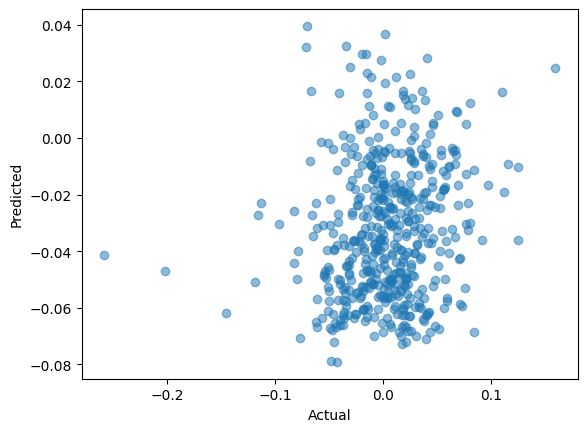

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()


In [ ]:
print(y_train.mean())
y_test.mean()


0.005361064134930134


np.float64(0.003585088367041242)

In [ ]:
print("Target mean:", y_test.mean())
print("Prediction mean:", y_pred.mean())
print("Target std:", y_test.std())
print("Prediction std:", y_pred.std())

Target mean: 0.003585088367041242
Prediction mean: -0.032390937
Target std: 0.0413077546868876
Prediction std: 0.024230717


In [ ]:
direction_accuracy = np.mean(
    (y_test > 0) == (y_pred > 0)
)

print("Directional Accuracy:", direction_accuracy)


Directional Accuracy: 0.4801587301587302


In [ ]:
print("Actual std:", y_test.std())
print("Pred std:", y_pred.std())


Actual std: 0.0413077546868876
Pred std: 0.024230717


In [ ]:
print("Train mean:", y_train.mean())
print("Test mean:", y_test.mean())
print("Pred mean:", y_pred.mean())


Train mean: 0.005361064134930134
Test mean: 0.003585088367041242
Pred mean: -0.032390937


In [ ]:
df2=pd.read_csv(r"C:\Users\vivaa\Downloads\AppleNewsStock.csv")

In [ ]:
df2.head()

,Date,Open,High,Low,Close,Adj Close,Volume,News
0,2006-12-01,13.114285,13.190000,12.871428,91.320000,13.045714,198769900,WHAT'S ON TONIGHT : 8 P.M. (TLC) ASHLEY JUDD A...
1,2006-12-04,13.125714,13.150000,12.928572,91.120003,13.017143,177384200,More on Housing Prices : The broadest governme...
2,2006-12-05,13.092857,13.190000,12.981428,91.269997,13.038571,165709600,NaN
3,2006-12-06,12.948571,13.055715,12.810000,89.830002,12.832857,159546100,Honoring R.W. Apple in Words and Food : About ...
4,2006-12-07,12.861428,12.928572,12.414286,87.040001,12.434286,251206900,"Homebuilders, and Worries Over Jobs, Lead a De..."


In [ ]:
df2.sort_values(by=['Date'],inplace=True)

In [ ]:
df2.head()

,Date,Open,High,Low,Close,Adj Close,Volume,News
0,2006-12-01,13.114285,13.190000,12.871428,91.320000,13.045714,198769900,WHAT'S ON TONIGHT : 8 P.M. (TLC) ASHLEY JUDD A...
1,2006-12-04,13.125714,13.150000,12.928572,91.120003,13.017143,177384200,More on Housing Prices : The broadest governme...
2,2006-12-05,13.092857,13.190000,12.981428,91.269997,13.038571,165709600,NaN
3,2006-12-06,12.948571,13.055715,12.810000,89.830002,12.832857,159546100,Honoring R.W. Apple in Words and Food : About ...
4,2006-12-07,12.861428,12.928572,12.414286,87.040001,12.434286,251206900,"Homebuilders, and Worries Over Jobs, Lead a De..."


In [ ]:
df2.tail()

,Date,Open,High,Low,Close,Adj Close,Volume,News
2512,2016-11-23,111.360001,111.510002,110.330002,111.230003,111.230003,27426400,NaN
2513,2016-11-25,111.129997,111.870003,110.949997,111.790001,111.790001,11475900,Fighting iOS Calendar Spam : Unsolicited invit...
2514,2016-11-28,111.430000,112.470001,111.389999,111.570000,111.570000,27194000,NaN
2515,2016-11-29,110.779999,112.029999,110.070000,111.459999,111.459999,28528800,NaN
2516,2016-11-30,111.599998,112.199997,110.269997,110.519997,110.519997,36162300,NaN


In [ ]:
df2.shape

(2517, 8)

In [ ]:
df4=pd.read_csv(r"C:\Users\vivaa\Downloads\apple_news_data.csv")

In [ ]:
df4.columns

Index(['date', 'title', 'content', 'link', 'symbols', 'tags',
       'sentiment_polarity', 'sentiment_neg', 'sentiment_neu',
       'sentiment_pos'],
      dtype='object')

In [ ]:
df4.drop(columns=['link', 'sentiment_neg', 'sentiment_neu','sentiment_pos'],inplace=True)

In [ ]:
df4.head()

,date,title,content,symbols,tags,sentiment_polarity
0,2024-11-27T16:39:00+00:00,Berkshire Stock Hits Record Even as Company Re...,"Warren Buffett’s caution, his advancing age, a...","0R2V.IL, AAPL.BA, AAPL.MX, AAPL.NEO, AAPL.SN, ...",NaN,0.0
1,2024-11-26T00:00:00+00:00,What Is a Stock Market Index?,What Is a Stock Market Index?,"AAPL.US, AMZN.US, MSFT.US",NaN,0.0
2,2024-11-26T00:00:00+00:00,"Could Investing $1,000 in Apple Make You a Mil...","Could Investing $1,000 in Apple Make You a Mil...",AAPL.US,NaN,0.0
3,2024-11-26T00:00:00+00:00,Dow Jones Industrial Average,Dow Jones Industrial Average,"AAPL.US, AMGN.US, AMZN.US, CSCO.US, GOOG.US, G...",NaN,0.0
4,2024-11-26T00:00:00+00:00,What Is the S&P 500 Index?,What Is the S&P 500 Index?,"AAPL.US, AMZN.US, GOOG.US, GOOGL.US, META.US, ...",NaN,0.0


In [ ]:
df4.shape

(29752, 6)

In [ ]:
df4['tags'].isna().sum()

np.int64(12188)

In [ ]:
df4['tags'].value_counts()

tags
APPLE                                                                                                                                                                        139
APPLE, APPLE WATCH                                                                                                                                                            29
APPLE, APPLE STOCK                                                                                                                                                            22
JARED BLIKRE                                                                                                                                                                  22
BERKSHIRE HATHAWAY, WARREN BUFFETT                                                                                                                                            18
                                                                                                              

In [ ]:
import re
import pandas as pd

# ---------------------------------------------------------
# Apple-related keywords (carefully grouped)
# ---------------------------------------------------------
APPLE_KEYWORDS = [
    # Company identifiers
    r"\bapple\b",
    r"\bapple inc\b",
    r"\baapl\b",

    # Executive & brand
    r"\btim cook\b",

    # Core products
    r"\biphone\b",
    r"\bipad\b",
    r"\bipod\b",
    r"\bimac\b",
    r"\bmacbook\b",
    r"\bmac\b",

    # Wearables & accessories
    r"\bapple watch\b",
    r"\biwatch\b",
    r"\bairpods\b",
    r"\bapple pencil\b",

    # Software & ecosystem
    r"\bios\b",
    r"\bmacos\b",
    r"\bwatchos\b",
    r"\bicloud\b",
    r"\bapp store\b",
    r"\bitunes\b",

    # Services
    r"\bapple music\b",
    r"\bapple tv\b",
    r"\bapple tv\+\b",
    r"\bapple pay\b",

    # Events & branding
    r"\bwwdc\b",
    r"\bapple keynote\b",

    # Informal / social mentions
    r"\bapple sticker\b",
]

# ---------------------------------------------------------
# Compile regex for efficiency
# ---------------------------------------------------------
APPLE_PATTERN = re.compile(
    "(" + "|".join(APPLE_KEYWORDS) + ")",
    flags=re.IGNORECASE
)

# ---------------------------------------------------------
# Filtering function
# ---------------------------------------------------------
def filter_apple_news(df, text_col="text"):
    """
    Keeps only rows where the text column contains Apple-related content.
    """
    df = df.copy()

    df[text_col] = df[text_col].fillna("").astype(str)

    mask = df[text_col].str.contains(APPLE_PATTERN, regex=True)

    return df[mask].reset_index(drop=True)

# ---------------------------------------------------------
# Usage
# ---------------------------------------------------------
apple_news_df = filter_apple_news(df4, text_col="tags")
apple_news_df1 = filter_apple_news(apple_news_df, text_col="symbols")


C:\Users\vivaa\AppData\Local\Temp\ipykernel_21608\3128809495.py:71: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df[text_col].str.contains(APPLE_PATTERN, regex=True)
C:\Users\vivaa\AppData\Local\Temp\ipykernel_21608\3128809495.py:71: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask = df[text_col].str.contains(APPLE_PATTERN, regex=True)


In [ ]:
apple_news_df1.shape

(9573, 6)

In [ ]:
apple_news_df1.head(1)

,date,title,content,symbols,tags,sentiment_polarity
0,2023-03-27T18:30:18+00:00,Apple Snaps AI Startup WaveOne Specializing In...,Apple Inc (NASDAQ: AAPL) has quietly snapped U...,"AAPL.MX, AAPL.US, AAPL34.SA, APC.F, APC.XETRA,...","APPLE INC, WAVEONE",0.972


In [ ]:
apple_news_df1.drop(columns=['symbols','tags'],inplace=True)
apple_news_df1["date"] = pd.to_datetime(apple_news_df1["date"])

In [ ]:
print(apple_news_df1['date'].min())
apple_news_df1['date'].max()

2016-02-19 15:05:00+00:00


Timestamp('2023-03-27 18:30:18+0000', tz='UTC')

In [ ]:
len(apple_news_df1['date'].unique())

9179

In [ ]:
daily_sentiment = (
    apple_news_df1.groupby("date")["sentiment_polarity"]
           .mean()
           .reset_index()
)


In [ ]:
daily_sentiment.shape


(9179, 2)

In [ ]:
daily_sentiment.dtypes

date                  datetime64[ns, UTC]
sentiment_polarity                float64
dtype: object

In [ ]:
daily_sentiment

,date,sentiment_polarity
0,2016-02-19 15:05:00+00:00,0.994
1,2019-04-22 16:30:00+00:00,-0.924
2,2019-05-14 12:40:00+00:00,-0.924
3,2019-05-15 02:00:00+00:00,-0.790
4,2019-05-20 16:40:00+00:00,-0.924
...,...,...
9174,2023-03-26 19:28:12+00:00,0.889
9175,2023-03-27 08:49:43+00:00,0.649
9176,2023-03-27 10:08:42+00:00,0.144
9177,2023-03-27 13:39:53+00:00,0.991


In [ ]:
df.columns

Index(['date', 'close', 'high', 'low', 'open', 'volume', 'daily_ret',
       'roll_mean_ret_5', 'roll_mean_ret_10', 'roll_vol_5', 'roll_vol_20',
       'momentum_10', 'vol_change', 'vol_roll_mean_5', 'ma_diff_10', 'target'],
      dtype='object')

In [ ]:
daily_sentiment.columns

Index(['date', 'sentiment_polarity'], dtype='object')

In [ ]:
df.index = pd.to_datetime(df.index).tz_localize(None)

daily_sentiment["date"] = (
    pd.to_datetime(daily_sentiment["date"])
    .dt.tz_localize(None)
)


In [ ]:
df.dtypes

date                datetime64[ns]
close                      float64
high                       float64
low                        float64
open                       float64
volume                     float64
daily_ret                  float64
roll_mean_ret_5            float64
roll_mean_ret_10           float64
roll_vol_5                 float64
roll_vol_20                float64
momentum_10                float64
vol_change                 float64
vol_roll_mean_5            float64
ma_diff_10                 float64
target                     float64
dtype: object

In [ ]:
daily_sentiment.dtypes

date                  datetime64[ns]
sentiment_polarity           float64
dtype: object

In [ ]:
df['date'] = df['date'].dt.date
daily_sentiment['date'] = daily_sentiment['date'].dt.date


In [ ]:
merged = df.merge(
    daily_sentiment,
    on='date',
    how='left'
)


In [ ]:
merged.reset_index(drop=True)

,date,close,high,low,open,volume,daily_ret,roll_mean_ret_5,roll_mean_ret_10,roll_vol_5,roll_vol_20,momentum_10,vol_change,vol_roll_mean_5,ma_diff_10,target,sentiment_polarity
0,2016-02-02,21.282389,24.010000,23.570000,23.855000,149428800.0,-0.020222,-0.010713,-0.001811,0.037028,0.026989,-0.022554,-0.087591,265412560.0,-0.025678,0.010795,NaN
1,2016-02-03,21.703623,24.209999,23.520000,23.750000,183857200.0,0.019793,0.006387,0.000034,0.021958,0.027105,-0.004546,0.230400,195488240.0,-0.005943,-0.016413,NaN
2,2016-02-04,21.878014,24.332500,23.797501,23.965000,185886800.0,0.008035,0.006560,0.001344,0.021969,0.026911,0.008558,0.011039,188122560.0,0.001193,-0.030481,NaN
3,2016-02-05,21.293692,24.230000,23.422501,24.129999,185672400.0,-0.026708,-0.005690,-0.006644,0.019391,0.025879,-0.067934,-0.001153,173723840.0,-0.018576,-0.000319,NaN
4,2016-02-08,21.517912,23.924999,23.260000,23.282499,216085600.0,0.010530,-0.001714,-0.003638,0.020462,0.025969,-0.039365,0.163800,184186160.0,-0.004195,0.017011,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10306,2026-02-02,269.757599,270.489990,259.209991,260.029999,73913400.0,0.040581,0.011303,0.005710,0.017725,0.015897,0.056667,-0.200447,64909220.0,0.059432,0.017865,NaN
10307,2026-02-03,269.228088,271.880005,267.609985,269.200012,64394700.0,-0.001963,0.008671,0.008969,0.018695,0.015574,0.092339,-0.128782,67858500.0,0.047985,0.016401,NaN
10308,2026-02-04,276.231506,278.950012,272.290009,272.290009,90545700.0,0.026013,0.015290,0.011186,0.017546,0.015901,0.116455,0.406105,77710040.0,0.063321,-0.002652,NaN
10309,2026-02-05,275.652069,279.500000,273.230011,278.130005,52977400.0,-0.002098,0.013436,0.010693,0.019044,0.015755,0.110972,-0.414910,74854920.0,0.049962,-0.051826,NaN


In [ ]:
merged["sentiment_polarity"].isna().mean()


np.float64(0.18456017845019881)

In [ ]:

#merged = df.merge(daily_sentiment,left_index=True,right_on="date",how="left") 
#merged["sentiment_polarity"] = merged["sentiment_polarity"].fillna(0)


In [ ]:
merged['sentiment_polarity'].unique()

array([   nan,  0.994, -0.924, ...,  0.224,  0.094,  0.144], shape=(1099,))

In [ ]:
merged.reset_index(drop=True)
merged.sort_values(by='date')
merged["date"] = pd.to_datetime(merged["date"])
merged.tail()

,date,close,high,low,open,volume,daily_ret,roll_mean_ret_5,roll_mean_ret_10,roll_vol_5,roll_vol_20,momentum_10,vol_change,vol_roll_mean_5,ma_diff_10,target,sentiment_polarity
10306,2026-02-02,269.757599,270.489990,259.209991,260.029999,73913400.0,0.040581,0.011303,0.005710,0.017725,0.015897,0.056667,-0.200447,64909220.0,0.059432,0.017865,NaN
10307,2026-02-03,269.228088,271.880005,267.609985,269.200012,64394700.0,-0.001963,0.008671,0.008969,0.018695,0.015574,0.092339,-0.128782,67858500.0,0.047985,0.016401,NaN
10308,2026-02-04,276.231506,278.950012,272.290009,272.290009,90545700.0,0.026013,0.015290,0.011186,0.017546,0.015901,0.116455,0.406105,77710040.0,0.063321,-0.002652,NaN
10309,2026-02-05,275.652069,279.500000,273.230011,278.130005,52977400.0,-0.002098,0.013436,0.010693,0.019044,0.015755,0.110972,-0.414910,74854920.0,0.049962,-0.051826,NaN
10310,2026-02-06,277.859985,280.910004,276.929993,277.119995,50453400.0,0.008010,0.014109,0.011619,0.018713,0.015676,0.121271,-0.047643,66456920.0,0.046394,-0.082800,NaN


In [ ]:
merged['date'].dtype

dtype('<M8[ns]')

In [ ]:
apple_news_df1['date'].dtype

datetime64[ns, UTC]

In [ ]:
apple_news_df1['date'] = apple_news_df1['date'].dt.tz_convert(None)


In [ ]:

merged_news_use = merged[
    (merged['date'] >= apple_news_df1['date'].min()) &
    (merged['date'] <= apple_news_df1['date'].max())
]


In [ ]:
merged_news_use["target_1d"] = np.log(
    merged_news_use["close"].shift(-1) /
    merged_news_use["close"]
)


C:\Users\vivaa\AppData\Local\Temp\ipykernel_7424\1077596179.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_news_use["target_1d"] = np.log(


In [ ]:
merged_news_use = merged_news_use.dropna()


In [ ]:
merged_news_use

,date,close,high,low,open,volume,daily_ret,roll_mean_ret_5,roll_mean_ret_10,roll_vol_5,roll_vol_20,momentum_10,vol_change,vol_roll_mean_5,ma_diff_10,target,sentiment_polarity,target_1d
809,2019-04-22,48.781242,51.235001,50.584999,50.707500,77758000.0,0.003286,0.005653,0.003789,0.007849,0.008133,0.038223,-0.196575,92620080.0,0.018555,0.000391,-0.924,0.014320
825,2019-05-14,45.169476,47.424999,46.352501,46.602501,146118800.0,0.015831,-0.013338,-0.005408,0.027597,0.021141,-0.056229,-0.363933,157133680.0,-0.062508,-0.010979,-0.924,0.011908
826,2019-05-15,45.710567,47.937500,46.505001,46.567501,106178800.0,0.011979,-0.010982,-0.009119,0.029480,0.021378,-0.089610,-0.273339,157297840.0,-0.042335,-0.043571,-0.790,-0.004410
829,2019-05-20,43.835880,46.087502,45.070000,45.880001,154449200.0,-0.031270,-0.002708,-0.012302,0.018620,0.021579,-0.118404,0.174372,134077760.0,-0.050759,-0.026903,-0.924,0.018989
832,2019-05-23,43.014668,45.134998,44.452499,44.950001,146118800.0,-0.017070,-0.011064,-0.010389,0.019209,0.022220,-0.101475,0.227947,132907600.0,-0.041143,-0.025880,-0.993,-0.003848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9586,2023-03-24,157.961609,160.339996,157.850006,158.860001,59196500.0,0.008306,0.006720,0.007682,0.009448,0.013586,0.079125,-0.124598,70020020.0,0.026855,0.028604,0.859,0.000000
9587,2023-03-24,157.961609,160.339996,157.850006,158.860001,59196500.0,0.008306,0.006720,0.007682,0.009448,0.013586,0.079125,-0.124598,70020020.0,0.026855,0.028604,0.778,-0.012370
9588,2023-03-27,156.019699,160.770004,157.869995,159.940002,52390300.0,-0.012294,0.001164,0.005126,0.011039,0.014056,0.051904,-0.114976,65769800.0,0.009181,0.048646,0.649,0.000000
9589,2023-03-27,156.019699,160.770004,157.869995,159.940002,52390300.0,-0.012294,0.001164,0.005126,0.011039,0.014056,0.051904,-0.114976,65769800.0,0.009181,0.048646,0.144,0.000000


In [ ]:
merged_news_use.shape

(8406, 18)

In [ ]:
merged_news_use["sentiment_polarity"] = \
    merged_news_use["sentiment_polarity"].shift(1)
merged_news_use.reset_index(drop=True,inplace=True)


In [ ]:
merged_news_use['sentiment_polarity']=merged_news_use['sentiment_polarity'].fillna(0)
merged_news_use.head()

,date,close,high,low,open,volume,daily_ret,roll_mean_ret_5,roll_mean_ret_10,roll_vol_5,roll_vol_20,momentum_10,vol_change,vol_roll_mean_5,ma_diff_10,target,sentiment_polarity,target_1d
0,2019-04-22,48.781242,51.235001,50.584999,50.707500,77758000.0,0.003286,0.005653,0.003789,0.007849,0.008133,0.038223,-0.196575,92620080.0,0.018555,0.000391,0.000,0.014320
1,2019-05-14,45.169476,47.424999,46.352501,46.602501,146118800.0,0.015831,-0.013338,-0.005408,0.027597,0.021141,-0.056229,-0.363933,157133680.0,-0.062508,-0.010979,-0.924,0.011908
2,2019-05-15,45.710567,47.937500,46.505001,46.567501,106178800.0,0.011979,-0.010982,-0.009119,0.029480,0.021378,-0.089610,-0.273339,157297840.0,-0.042335,-0.043571,-0.924,-0.004410
3,2019-05-20,43.835880,46.087502,45.070000,45.880001,154449200.0,-0.031270,-0.002708,-0.012302,0.018620,0.021579,-0.118404,0.174372,134077760.0,-0.050759,-0.026903,-0.790,0.018989
4,2019-05-23,43.014668,45.134998,44.452499,44.950001,146118800.0,-0.017070,-0.011064,-0.010389,0.019209,0.022220,-0.101475,0.227947,132907600.0,-0.041143,-0.025880,-0.924,-0.003848


In [ ]:
target_col = "target_1d"

# Drop columns you should not train on
drop_cols = [target_col,'target']

if "Close" in merged_news_use.columns:
    drop_cols.append("close")

if "date" in merged_news_use.columns:
    drop_cols.append("date")

X = merged_news_use.drop(columns=drop_cols)
y = merged_news_use[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Feature columns:", list(X.columns))


X shape: (8406, 15)
y shape: (8406,)
Feature columns: ['close', 'high', 'low', 'open', 'volume', 'daily_ret', 'roll_mean_ret_5', 'roll_mean_ret_10', 'roll_vol_5', 'roll_vol_20', 'momentum_10', 'vol_change', 'vol_roll_mean_5', 'ma_diff_10', 'sentiment_polarity']


In [ ]:
test_size = 0.2
split_index = int(len(X) * (1 - test_size))

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

print("Train last date:", X_train.index.max())
print("Test first date:", X_test.index.min())


Train size: (6724, 15)
Test size: (1682, 15)
Train last date: 6723
Test first date: 6724


In [ ]:
from xgboost import XGBRegressor
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Optional: center target (recommended)
train_mean = y_train.mean()
y_train_centered = y_train - train_mean

model = XGBRegressor(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.03,
    random_state=42
)

model.fit(X_train, y_train_centered)

# Predict
y_pred_centered = model.predict(X_test)
y_pred = y_pred_centered + train_mean

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
corr = np.corrcoef(y_test, y_pred)[0, 1]

print("MAE:", mae)
print("RMSE:", rmse)
print("Correlation:", corr)


MAE: 0.0026934902559270064
RMSE: 0.006283011456084927
Correlation: 0.021962787048372685


In [ ]:
X_no_news = X.drop(columns=["sentiment_polarity"])

X_train_nn = X_no_news.iloc[:split_index]
X_test_nn  = X_no_news.iloc[split_index:]

# Train again
train_mean_nn = y_train.mean()
y_train_centered_nn = y_train - train_mean_nn

model_nn = XGBRegressor(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.03,
    random_state=42
)

model_nn.fit(X_train_nn, y_train_centered_nn)

y_pred_centered_nn = model_nn.predict(X_test_nn)
y_pred_nn = y_pred_centered_nn + train_mean_nn

corr_nn = np.corrcoef(y_test, y_pred_nn)[0, 1]

print("Correlation without sentiment:", corr_nn)


Correlation without sentiment: 0.03604607125183995


In [ ]:
import pandas as pd

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(10))


high                  0.090878
vol_roll_mean_5       0.087737
roll_vol_5            0.085743
low                   0.084364
daily_ret             0.078185
sentiment_polarity    0.073785
roll_mean_ret_10      0.068783
close                 0.061568
vol_change            0.055758
volume                0.054711
dtype: float32


In [ ]:
print("Columns in X:")
print(X.columns)

print("\nDoes sentiment_score exist?")
print("sentiment_polarity" in X.columns)

print("\nSentiment stats:")
print(X["sentiment_polarity"].describe())


Columns in X:
Index(['close', 'high', 'low', 'open', 'volume', 'daily_ret',
       'roll_mean_ret_5', 'roll_mean_ret_10', 'roll_vol_5', 'roll_vol_20',
       'momentum_10', 'vol_change', 'vol_roll_mean_5', 'ma_diff_10',
       'sentiment_polarity'],
      dtype='object')

Does sentiment_score exist?
True

Sentiment stats:
count    8406.000000
mean        0.409415
std         0.604561
min        -0.998000
25%         0.000000
50%         0.599000
75%         0.977000
max         1.000000
Name: sentiment_polarity, dtype: float64


In [ ]:
print("Target std:", y_test.std())
print("Prediction std:", np.std(y_pred))


Target std: 0.005225036573386821
Prediction std: 0.0034125810360483722


In [ ]:
import numpy as np

X_shuffled = X.copy()
X_shuffled["sentiment_polarity"] = np.random.permutation(X_shuffled["sentiment_polarity"])

X_train_s = X_shuffled.iloc[:split_index]
X_test_s  = X_shuffled.iloc[split_index:]

model_s = XGBRegressor(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.03,
    random_state=42
)

model_s.fit(X_train_s, y_train_centered)
y_pred_s = model_s.predict(X_test_s) + train_mean

print("Correlation with shuffled sentiment:",
      np.corrcoef(y_test, y_pred_s)[0,1])


Correlation with shuffled sentiment: 0.027509714709856838


In [ ]:
X_shuffled_full = X.copy()
X_shuffled_full["sentiment_polarity"] = np.random.permutation(
    X_shuffled_full["sentiment_polarity"].values
)

X_train_sf = X_shuffled_full.iloc[:split_index]
X_test_sf  = X_shuffled_full.iloc[split_index:]

model_sf = XGBRegressor(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.03,
    random_state=42
)

model_sf.fit(X_train_sf, y_train_centered)

y_pred_sf = model_sf.predict(X_test_sf) + train_mean

corr_sf = np.corrcoef(y_test, y_pred_sf)[0, 1]

print("Correlation with fully shuffled sentiment: ", corr_sf)


Correlation with fully shuffled sentiment: 0.030007394754411967


In [ ]:
import dhruvprep as eda

In [ ]:
eda.basic_summary(df)

{'shape': (2519, 16),
 'missing_values': date                0
 close               0
 high                0
 low                 0
 open                0
 volume              0
 daily_ret           0
 roll_mean_ret_5     0
 roll_mean_ret_10    0
 roll_vol_5          0
 roll_vol_20         0
 momentum_10         0
 vol_change          0
 vol_roll_mean_5     0
 ma_diff_10          0
 target              0
 dtype: int64,
 'describe':                                 date        close         high          low  \
 count                           2519  2519.000000  2519.000000  2519.000000   
 mean   2021-02-01 02:08:37.348153856   116.369375   119.866880   117.396337   
 min              2016-02-02 00:00:00    20.584820    22.917500    22.367500   
 25%              2018-08-01 12:00:00    41.941469    44.920000    44.143751   
 50%              2021-02-02 00:00:00   122.587074   127.129997   124.260002   
 75%              2023-08-03 12:00:00   172.836395   177.239998   173.764999   
 max 